## Open Ended Lab
### Subject : Programming For AI
### Task 1: Data Analytics & Visualization Project

- Question 1 : Load & Inspect Data: Use Pandas to load the dataset, Display structure, missing values, and basic statistics

In [9]:
# Importing required libraries
import pandas as pd

# Load dataset
df = pd.read_csv("StudentsPerformance.csv")
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [13]:
# Check missing values
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [15]:
# Basic Statistics
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


- Question 2 : Data Cleaning: Handle missing values, Remove duplicates, Fix data types <br>(dates, categories, numbers), Clean inconsistent text formats (capitalization, spacing)

In [20]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [22]:
# Remove Duplicates if any available
df.duplicated().sum()

0

In [24]:
df.drop_duplicates(inplace = True) # There are no duplicate values in the dataset

In [28]:
# Fix datatypes
df.dtypes # All datatypes are correct as identified from the output

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

In [30]:
# Cleaning text data
df.columns = df.columns.str.strip().str.lower()

for col in df.select_dtypes(include = "object"):
    df[col] = df[col].str.strip().str.lower()

In [32]:
# Saving the cleaned dataset
df.to_csv("StudentsPerformance_cleaned.csv", index = False)

- Question 3 :Exploratory Data Analysis (EDA): Perform trend analysis,<br> correlation analysis, and grouping Identify outliers

In [38]:
# Trend Analysis
# Average marks in subjects by gender
df.groupby("gender")[["math score", "reading score", "writing score"]].mean()


,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


In [46]:
# Correlation Analysis
# It shows how different marks/scores are related
df[["math score", "reading score", "writing score"]].corr()

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


In [44]:
# Outlier Detection
df.describe(percentiles=[0.01, 0.99])

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
1%,27.99000,31.990000,31.980000
50%,66.00000,70.000000,69.000000
99%,98.01000,100.000000,100.000000
max,100.00000,100.000000,100.000000


- Question 4  Visualizations (Seaborn): Create at least 5 charts from the following:
- Heatmap
- Pairplot
- Time-series line plot
- Box/violin plot
- Barplot/histogram

In [49]:
# Visualization (Seaborn)
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style = "whitegrid")


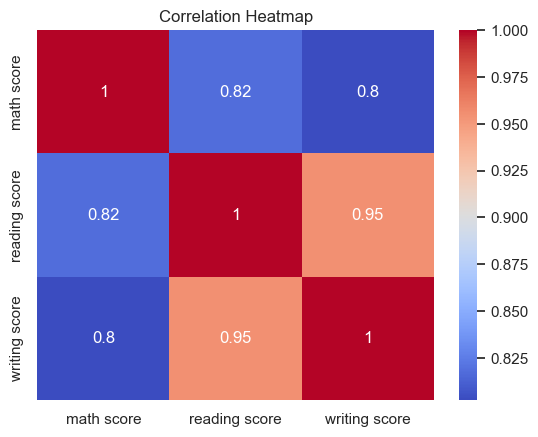

In [51]:
# Heatmap (Correlation)
plt.figure()
sns.heatmap(df[["math score", "reading score", "writing score"]].corr(),
           annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

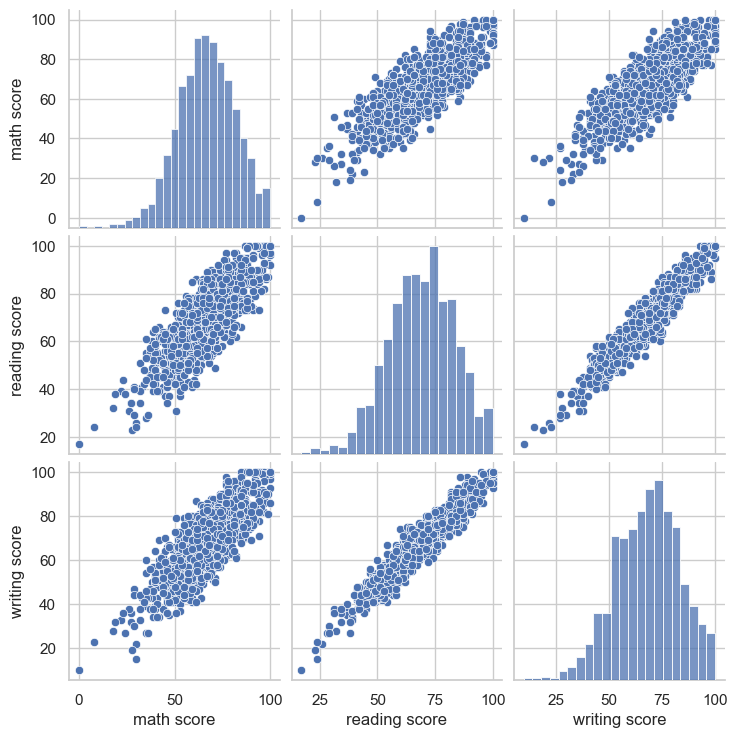

In [57]:
# Pairplot
sns.pairplot(df[["math score", "reading score", "writing score"]])
plt.show()

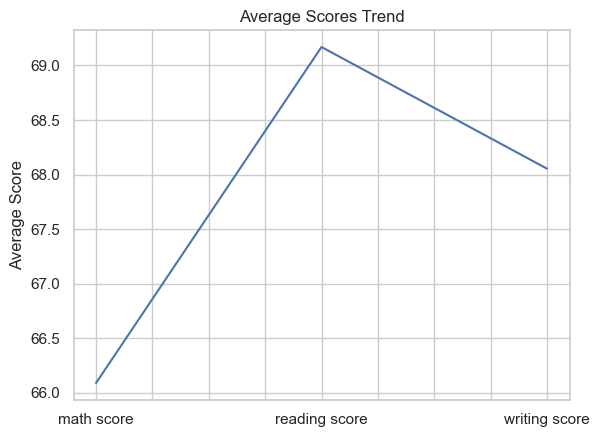

In [59]:
# Time - Series Line Plot
df[["math score", "reading score", "writing score"]].mean().plot(kind="line")
plt.title("Average Scores Trend")
plt.ylabel("Average Score")
plt.show()

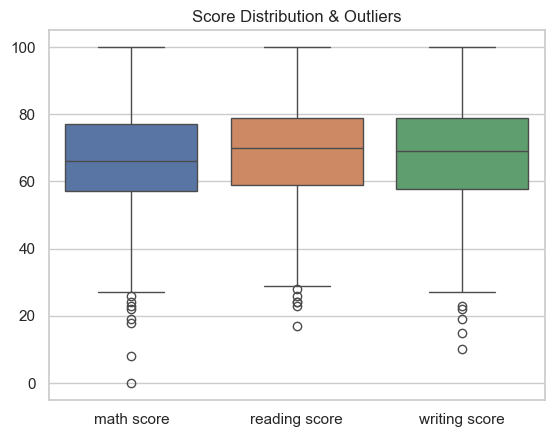

In [61]:
# Box Plot (Outliers)
sns.boxplot(data=df[["math score", "reading score", "writing score"]])
plt.title("Score Distribution & Outliers")
plt.show()

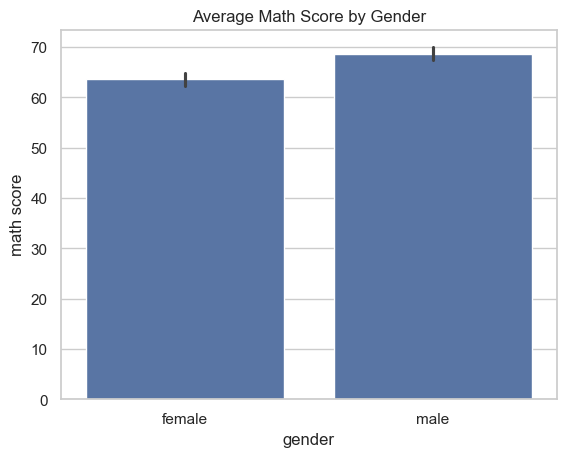

In [65]:
# Bar Plot
sns.barplot(x="gender", y="math score", data = df)
plt.title("Average Math Score by Gender")
plt.show()

### Insights and Summary - 10 key points
- 1 Reading and writing scores have a strong correlationif a students is having higher score in<br> reading their
writing score is also higher.
- 2 Students with higher parental education tend to score better.
- 3 Math Scores show highly more variation than reading scores.
- 4 Female students perform better in reading and writing on average.
- 5 Male students slightly outperform females in math.
- 6 Test preparation course participants score higher overall.
- 7 No extreme outliers were found, indicating clean data quality.
- 8 Writing scores closely follow reading performance
- 9 Socio-educational background impacts student performance.
- 10 Balanced study preparation improves all subject scores.


### Task 2: Image Processing & Computer Vision Project

1. Custom Image Filters (Design any 3)
- Examples:
- Sketch/outline effect
- Cartoon filter
- Edge enhancement
- Sharpening + blur combination
- Vintage/black & white filter

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


(-0.5, 1279.5, 852.5, -0.5)

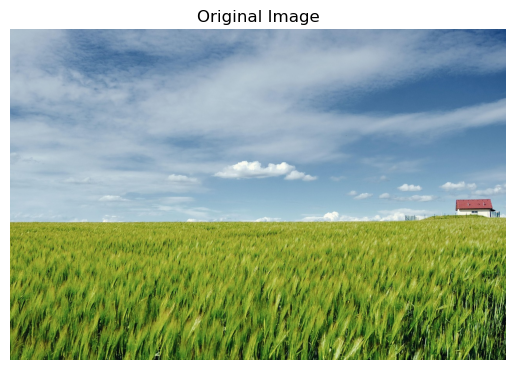

In [11]:
# Read and Display Image
img = cv2.imread("image1.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Original Image")
plt.axis("off")


(-0.5, 1279.5, 852.5, -0.5)

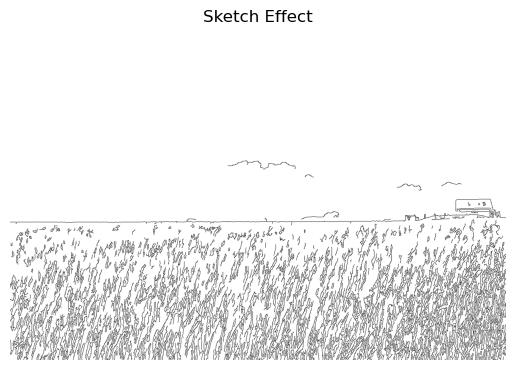

In [15]:
# Filter 1 - Sketch / Outline Effect
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
blur = cv2.GaussianBlur(gray, (5,5),0)
edges = cv2.Canny(blur, 50, 150)
sketch = cv2.bitwise_not(edges)

plt.imshow(sketch, cmap="gray")
plt.title("Sketch Effect")
plt.axis("off")

(-0.5, 1279.5, 852.5, -0.5)

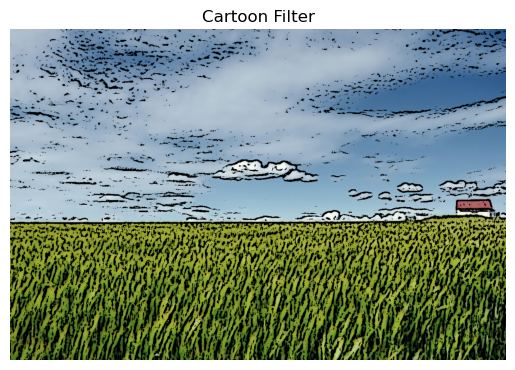

In [24]:
# Filter 2 - Cartoon Effect
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
gray_blur = cv2.medianBlur(gray, 7)
edges = cv2.adaptiveThreshold(
    gray_blur, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY, 9, 2
)

color = cv2.bilateralFilter(img, 9, 250, 250)
cartoon = cv2.bitwise_and(color, color, mask = edges)

plt.imshow(cartoon)
plt.title("Cartoon Filter")
plt.axis("off")

(-0.5, 1279.5, 852.5, -0.5)

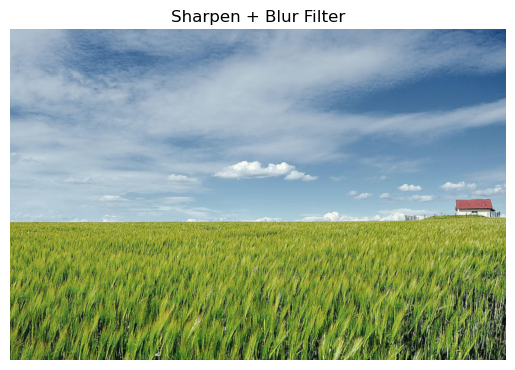

In [26]:
# Filter 3 : Sharpening + Blur Combination
kernel = np.array([[0, -1, 0],
                  [-1, 5, -1],
                  [0, -1, 0]])

sharpened = cv2.filter2D(img, -1, kernel)
soft_blur = cv2.GaussianBlur(sharpened, (3,3), 0)

plt.imshow(soft_blur)
plt.title("Sharpen + Blur Filter")
plt.axis("off")

- Question 2 : Image Feature Extraction: Compare color histograms of two images,<br> Use ORB/SIFT/SURF to detect and match keypoints

In [33]:
# Comparing images using color histograms
# Load the images and import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

img1 = cv2.imread("image1.jpg")
img2 = cv2.imread("image2.jpg")

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Compute Color Histograms
histogram1 = cv2.calcHist([img1], [0, 1 , 2], None, [8, 8, 8], [0,256,0, 256,0,256])
histogram2 = cv2.calcHist([img2], [0, 1 , 2], None, [8, 8, 8], [0,256,0, 256,0,256])

# Normalize histograms
cv2.normalize(histogram1, histogram2)
cv2.normalize(histogram2, histogram2)

similarity = cv2.compareHist(histogram1, histogram2, cv2.HISTCMP_CORREL)
print("Histogram Similartity Score:", similarity)



Histogram Similartity Score: 0.9999999999999998


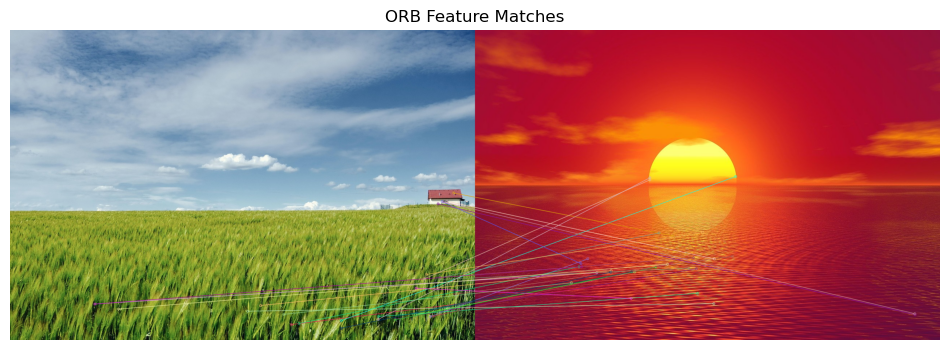

In [37]:
# Feature Detection using ORB
gray1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)

orb = cv2.ORB_create(nfeatures=1000)

kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

matched_img = cv2.drawMatches(
    img1, kp1,
    img2, kp2,
    matches[:30], None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(12,5))
plt.imshow(matched_img)
plt.title("ORB Feature Matches")
plt.axis("off")
plt.show()



- Question 3 Image Collage Creator: Load 4–6 images, Resize and arrange <br>in a custom layout, Add labels/text on each image.

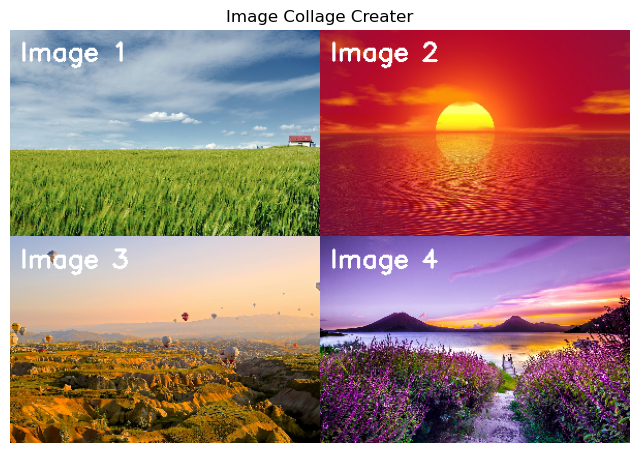

In [3]:
# Importing all the required Libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Loading the all 4 images for collage
img1 = cv2.imread("image1.jpg")
img2 = cv2.imread("image2.jpg")
img3 = cv2.imread("image3.jpg")
img4 = cv2.imread("image4.jpg")

# Convert BGR to RGB for display
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)
img4 = cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)

# Resize all the 4 images - uniform size
# Define width and height
width, height = 300, 200

img1 = cv2.resize(img1, (width, height))
img2 = cv2.resize(img2, (width, height))
img3 = cv2.resize(img3, (width, height))
img4 = cv2.resize(img4, (width, height))

# Add label and text to the images
font = cv2.FONT_HERSHEY_SIMPLEX

cv2.putText(img1, "Image 1", (10,30), font, 0.8, (255,255,255), 2)
cv2.putText(img2, "Image 2", (10,30), font, 0.8, (255,255,255), 2)
cv2.putText(img3, "Image 3", (10,30), font, 0.8, (255,255,255), 2)
cv2.putText(img4, "Image 4", (10,30), font, 0.8, (255,255,255), 2)

# Creating custom layout (2x2 Grid)
top_row = np.hstack((img1, img2))
bottom_row = np.hstack((img3, img4))

collage = np.vstack((top_row, bottom_row))

# Displaying the final collage
plt.figure(figsize=(8,6))
plt.imshow(collage)
plt.title("Image Collage Creater")
plt.axis("off")
plt.show()

## Task 3: Scientific Computing & Time Series Modeling
### Task Description:
- Solve a real-world problem using NumPy simulations, Pandas time series analysis, and data storytelling.

### Requirements:
A. NumPy Scientific Simulation
Choose one:
1. Random walk / Brownian motion
2. Temperature simulation model
3. Traffic flow simulation
4. Predator–prey population model
5. Projectile motion
- Must include:
- Mathematical model
- NumPy implementation
- Line plots showing simulation over time

## Task 3 – Part A: NumPy Scientific Simulation
### Random Walk / Brownian Motion

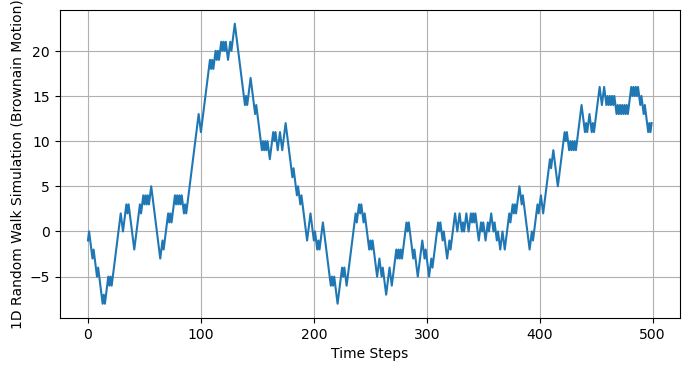

In [6]:
# Import all the required librararies
import numpy as np
import matplotlib.pyplot as plt

# Define simulation parameters
np.random.seed(42)
steps = 500

# Generate random steps
# Random steps: -1 or +1
random_steps = np.random.choice([-1, 1], size=steps)

# Cumulative sum gives position st each time step
position = np.cumsum(random_steps)

# Visualization
plt.figure(figsize=(8,4))
plt.plot(position)
plt.xlabel("Time Steps")
plt.ylabel("1D Random Walk Simulation (Brownain Motion)")
plt.grid(True)
plt.show()

## B. Time Series Forecasting (Pandas):
### Choose any time series dataset (stock market, weather,<br> electricity usage, inflation, or COVID-19):
 - Clean and preprocess data
 -  Detect trends, seasonality, anomalies
 - Apply forecasting method (moving average, rolling mean, exponential smoothing)

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("covid_19.csv")
df.head()

,country,continent,population,day,time,Cases,Recovered,Deaths,Tests
0,Saint-Helena,Africa,6115.0,2024-06-30,2024-06-30T16:15:16+00:00,2166,2.0,NaN,NaN
1,Falkland-Islands,South-America,3539.0,2024-06-30,2024-06-30T16:15:16+00:00,1930,1930.0,NaN,8632.0
2,Montserrat,North-America,4965.0,2024-06-30,2024-06-30T16:15:16+00:00,1403,1376.0,8.0,17762.0
3,Diamond-Princess,NaN,NaN,2024-06-30,2024-06-30T16:15:16+00:00,712,699.0,13.0,NaN
4,Vatican-City,Europe,799.0,2024-06-30,2024-06-30T16:15:16+00:00,29,29.0,NaN,NaN


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     238 non-null    object 
 1   continent   236 non-null    object 
 2   population  229 non-null    float64
 3   day         238 non-null    object 
 4   time        238 non-null    object 
 5   Cases       238 non-null    int64  
 6   Recovered   190 non-null    float64
 7   Deaths      233 non-null    float64
 8   Tests       213 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 16.9+ KB


In [61]:
 df['datetime'] = pd.to_datetime(df['day'] + ' ' + df['time'])


C:\Users\PC\AppData\Local\Temp\ipykernel_18196\2752174466.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['datetime'] = pd.to_datetime(df['day'] + ' ' + df['time'])


In [25]:
df.set_index("datetime", inplace=True)

In [27]:
# Sort by time
df.sort_index(inplace=True)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 238 entries, 2024-06-30 16:15:10+00:00 to 2024-06-30 16:15:16+00:00
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     238 non-null    object 
 1   continent   236 non-null    object 
 2   population  229 non-null    float64
 3   day         238 non-null    object 
 4   time        238 non-null    object 
 5   Cases       238 non-null    int64  
 6   Recovered   190 non-null    float64
 7   Deaths      233 non-null    float64
 8   Tests       213 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.6+ KB


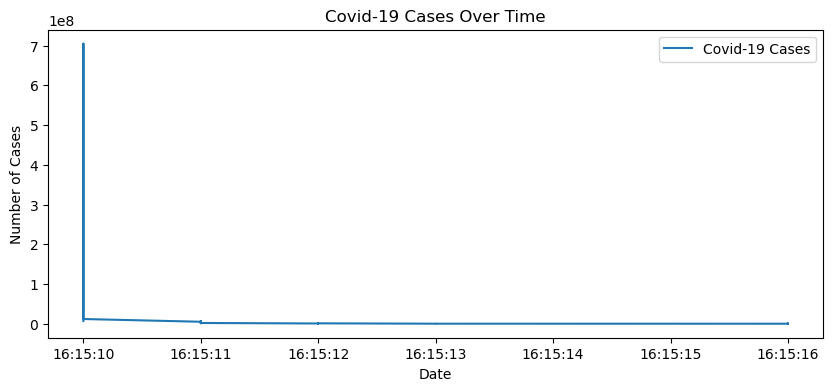

In [43]:
plt.figure(figsize=(10,4))
plt.plot(df["Cases"], label = "Covid-19 Cases")
plt.title("Covid-19 Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Cases")
plt.legend()
plt.show()

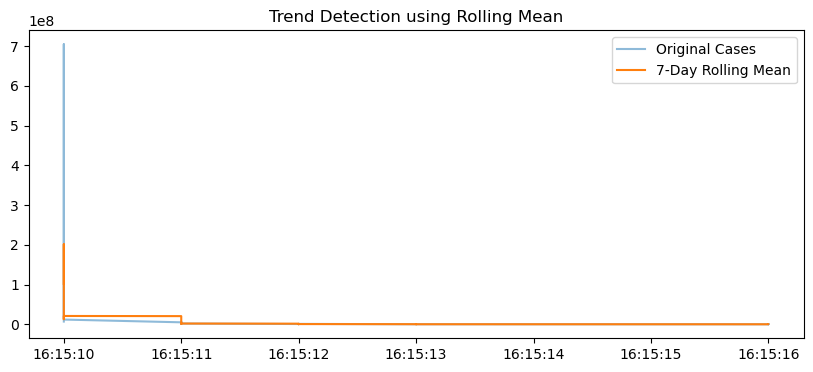

In [47]:
df["rolling_mean_7"] = df["Cases"].rolling(window=7).mean()

plt.figure(figsize=(10,4))
plt.plot(df["Cases"], alpha=0.5, label="Original Cases")
plt.plot(df["rolling_mean_7"], label="7-Day Rolling Mean")
plt.title("Trend Detection using Rolling Mean")
plt.legend()
plt.show()


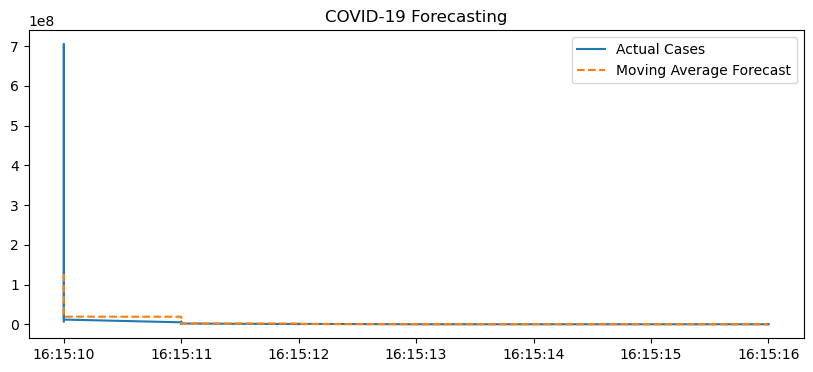

In [49]:
df["forecast"] = df["Cases"].rolling(window=14).mean()

plt.figure(figsize=(10,4))
plt.plot(df["Cases"], label="Actual Cases")
plt.plot(df["forecast"], linestyle="--", label="Moving Average Forecast")
plt.title("COVID-19 Forecasting")
plt.legend()
plt.show()
